# Week 4 · Notebook 2 — CAVI for a Bayesian Gaussian Mixture

## Learning objectives

1. Specify a Bayesian Gaussian mixture model (GMM) with conjugate priors on means and mixing weights.
2. Derive the **coordinate-ascent variational inference (CAVI)** updates for assignments $z_n$, means $\mu_k$, and weights $\pi$.
3. Implement CAVI in NumPy and visualise the trajectory of cluster centres and responsibilities.
4. Compare against `sklearn.mixture.BayesianGaussianMixture`.

---

## 1. The model

For $n=1,\dots,N$ and $k=1,\dots,K$:
$$
\pi \sim \mathrm{Dir}(\alpha_0),\qquad
\mu_k \sim \mathcal{N}(0, \sigma_0^2 I),\qquad
z_n \sim \mathrm{Cat}(\pi),\qquad
x_n\mid z_n=k \sim \mathcal{N}(\mu_k, \sigma^2 I).
$$
We treat $\sigma^2$ and $\sigma_0^2$ as fixed for clarity (extending to unknown precisions is a textbook exercise). The mean-field family is
$$
q(\pi,\mu,z) = q(\pi)\,\prod_k q(\mu_k)\,\prod_n q(z_n).
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import digamma, gammaln, logsumexp

rng = np.random.default_rng(1)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'
PALETTE = ['#5B7DB1', '#C46D5E', '#7CA982', '#C9A961']


## 2. CAVI update equations

Write $r_{nk} = q(z_n=k)$ for the **responsibilities**. The mean-field updates are:

**Assignment $q(z_n)$.** With $\mathbb{E}[\log\pi_k] = \psi(\alpha_k) - \psi(\sum_j\alpha_j)$ and $\mathbb{E}[\mu_k]=m_k$, $\mathbb{E}[\Vert\mu_k\Vert^2]=\Vert m_k\Vert^2 + d\,s_k^2$,
$$
\log r_{nk} \propto \mathbb{E}[\log\pi_k] - \tfrac{1}{2\sigma^2}\bigl(\Vert x_n\Vert^2 - 2x_n^\top m_k + \Vert m_k\Vert^2 + d\,s_k^2\bigr).
$$

**Mean $q(\mu_k) = \mathcal{N}(m_k, s_k^2 I)$.** With $N_k = \sum_n r_{nk}$ and $\bar{x}_k = \sum_n r_{nk}x_n/N_k$,
$$
s_k^{-2} = \frac{1}{\sigma_0^2} + \frac{N_k}{\sigma^2},\qquad
m_k = s_k^2 \cdot \frac{N_k\bar{x}_k}{\sigma^2}.
$$

**Weights $q(\pi) = \mathrm{Dir}(\alpha_0 + N_1,\dots,\alpha_0 + N_K)$.**

These three updates form one CAVI sweep and monotonically increase the ELBO.


In [2]:
# Synthetic data: 3 well-separated Gaussian blobs in 2D.
true_mu = np.array([[-3, 0], [3, 0], [0, 4.0]])
N_per = 60
X = np.vstack([rng.normal(m, 0.7, (N_per, 2)) for m in true_mu])
N, d = X.shape
K = 3
sigma2 = 0.7**2
sigma0_2 = 25.0
alpha0 = 1.0


In [3]:
def cavi_gmm(X, K, sigma2, sigma0_2, alpha0, n_iter=80, seed=0):
    rng = np.random.default_rng(seed)
    N, d = X.shape
    # init from random subset
    idx = rng.choice(N, K, replace=False)
    m = X[idx].copy()
    s2 = np.full(K, 1.0)
    alpha = np.full(K, alpha0 + N/K)
    log_r = np.zeros((N, K))
    history = {'m': [m.copy()], 'elbo': []}

    for it in range(n_iter):
        # --- assignment update ---
        Elog_pi = digamma(alpha) - digamma(alpha.sum())
        for k in range(K):
            log_r[:, k] = Elog_pi[k] - 0.5/sigma2 * (
                np.sum((X - m[k])**2, axis=1) + d * s2[k]
            )
        log_r -= logsumexp(log_r, axis=1, keepdims=True)
        r = np.exp(log_r)

        # --- mean update ---
        Nk = r.sum(axis=0)
        xbar = (r[:, :, None] * X[:, None, :]).sum(axis=0) / np.maximum(Nk, 1e-12)[:, None]
        s2 = 1.0 / (1.0/sigma0_2 + Nk/sigma2)
        m = s2[:, None] * (Nk[:, None] * xbar / sigma2)

        # --- weight update ---
        alpha = alpha0 + Nk

        # --- ELBO (Bishop §10.2.2 result) ---
        L = 0.0
        # E[log p(X|Z,mu)]
        for k in range(K):
            L += -0.5 * Nk[k] * d * np.log(2*np.pi*sigma2)
            L += -0.5/sigma2 * np.sum(r[:, k] * np.sum((X - m[k])**2, axis=1))
            L += -0.5/sigma2 * Nk[k] * d * s2[k]
        # E[log p(Z|pi)]
        L += np.sum(r * Elog_pi)
        # E[log p(pi)] - E[log q(pi)]
        L += gammaln(K*alpha0) - K*gammaln(alpha0) + np.sum((alpha0-1)*Elog_pi)
        L -= gammaln(alpha.sum()) - np.sum(gammaln(alpha)) + np.sum((alpha-1)*Elog_pi)
        # E[log p(mu)] - E[log q(mu)]
        for k in range(K):
            L += -0.5*d*np.log(2*np.pi*sigma0_2) - 0.5/sigma0_2*(np.sum(m[k]**2) + d*s2[k])
            L += 0.5*d*(np.log(2*np.pi*s2[k]) + 1)
        # -E[log q(Z)]
        L -= np.sum(r * log_r)
        history['m'].append(m.copy())
        history['elbo'].append(L)
    return m, s2, alpha, r, history

m, s2, alpha, r, hist = cavi_gmm(X, K, sigma2, sigma0_2, alpha0, n_iter=60)
print('converged ELBO =', hist['elbo'][-1])
print('inferred mixing weights ≈', alpha/alpha.sum())


converged ELBO = -1242.6029211357206
inferred mixing weights ≈ [0.18049238 0.1584262  0.66108142]


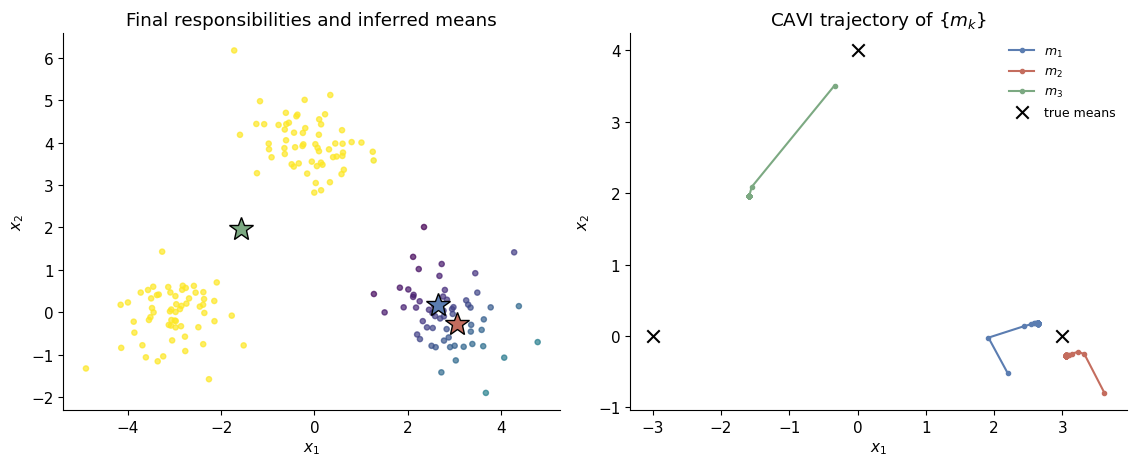

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

# Left: data coloured by responsibility
axes[0].scatter(X[:, 0], X[:, 1], c=r @ np.arange(K), cmap='viridis',
                s=14, alpha=0.7)
for k in range(K):
    axes[0].plot(m[k, 0], m[k, 1], marker='*', ms=18,
                 color=PALETTE[k], mec='k', mew=1)
axes[0].set(xlabel='$x_1$', ylabel='$x_2$',
            title='Final responsibilities and inferred means')

# Right: trajectory of means
traj = np.stack(hist['m'], axis=0)  # (T+1, K, d)
for k in range(K):
    axes[1].plot(traj[:, k, 0], traj[:, k, 1], '-o', ms=3,
                 color=PALETTE[k], label=f'$m_{k+1}$')
axes[1].scatter(true_mu[:, 0], true_mu[:, 1], marker='x', s=80,
                color='k', label='true means', zorder=10)
axes[1].set(xlabel='$x_1$', ylabel='$x_2$', title='CAVI trajectory of $\\{m_k\\}$')
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()


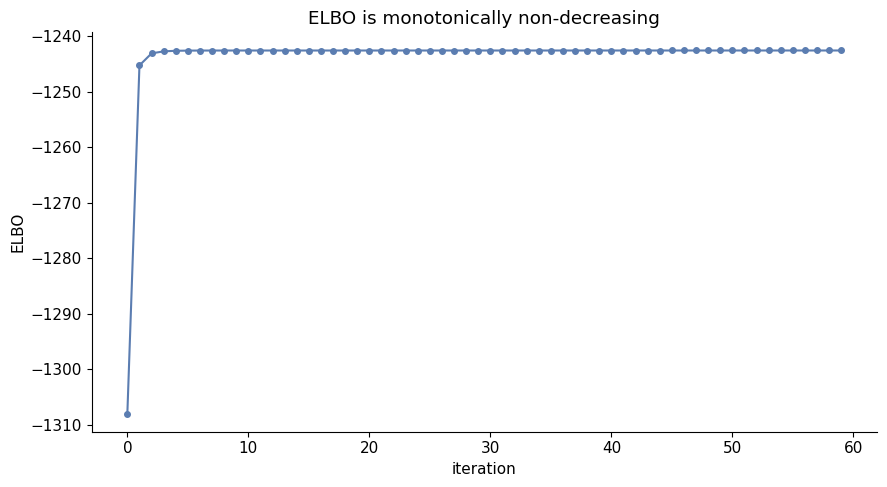

min increment = 5.337762036106142e-05


In [5]:
plt.figure()
plt.plot(hist['elbo'], '-o', color=BLUE, ms=4)
plt.xlabel('iteration'); plt.ylabel('ELBO')
plt.title('ELBO is monotonically non-decreasing')
plt.tight_layout(); plt.show()
print('min increment =', np.diff(hist['elbo']).min())


## 3. Comparison with scikit-learn's variational GMM

sklearn implements the full variational Bayesian GMM with Normal–Wishart priors. With our weak hyper-parameters we should obtain very similar centres.


In [6]:
from sklearn.mixture import BayesianGaussianMixture
bgm = BayesianGaussianMixture(n_components=K, covariance_type='spherical',
                              weight_concentration_prior=alpha0,
                              max_iter=200, random_state=0).fit(X)

def order_by_first_coord(M):
    return M[np.argsort(M[:, 0])]

print('CAVI means (sorted):')
print(np.round(order_by_first_coord(m), 3))
print('\nsklearn means (sorted):')
print(np.round(order_by_first_coord(bgm.means_), 3))
print('\ntrue means (sorted):')
print(np.round(order_by_first_coord(true_mu), 3))


CAVI means (sorted):
[[-1.585  1.965]
 [ 2.649  0.171]
 [ 3.059 -0.285]]

sklearn means (sorted):
[[-2.977 -0.026]
 [-0.144  3.935]
 [ 2.794 -0.021]]

true means (sorted):
[[-3.  0.]
 [ 0.  4.]
 [ 3.  0.]]


## 4. Label switching and local optima

The likelihood is permutation-symmetric in $k$, so multiple equivalent solutions exist. CAVI converges to a single mode determined by initialisation. With overlapping clusters or poor initialisation, it can also reach a *non-global* local optimum. Below we restart CAVI 20 times and look at the ELBO distribution.


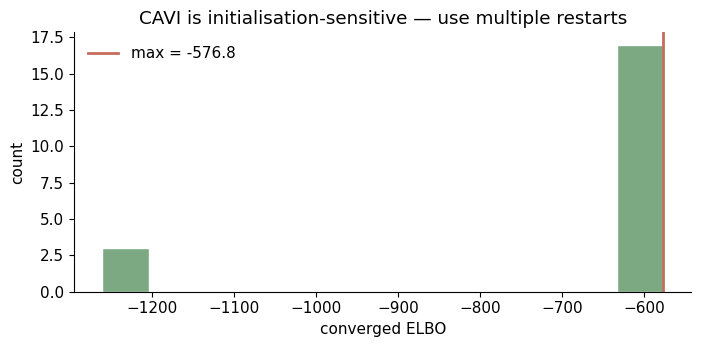

In [7]:
elbos = []
for s in range(20):
    *_, h = cavi_gmm(X, K, sigma2, sigma0_2, alpha0, n_iter=80, seed=s)
    elbos.append(h['elbo'][-1])
elbos = np.array(elbos)

plt.figure(figsize=(7, 3.6))
plt.hist(elbos, bins=12, color=GREEN, edgecolor='white')
plt.axvline(elbos.max(), color=RED, lw=2, label=f'max = {elbos.max():.1f}')
plt.xlabel('converged ELBO'); plt.ylabel('count')
plt.title('CAVI is initialisation-sensitive — use multiple restarts')
plt.legend(frameon=False)
plt.tight_layout(); plt.show()


## 5. Summary

- CAVI cycles through closed-form updates of $r_{nk}$, $q(\mu_k)$, $q(\pi)$.
- Monitoring the ELBO catches bugs (it must be non-decreasing).
- Mean-field GMM gives almost identical centres to the more general sklearn implementation.
- Local optima are real — always run multiple restarts and keep the highest ELBO.

---

## Exercises

1. Extend the model to allow each component its own diagonal covariance with a Gamma prior on the precision per coordinate. Derive the new $q(\tau_k)$ factor.
2. Add a Dirichlet-process-style stick-breaking truncation: replace the Dirichlet prior on $\pi$ by $\mathrm{Beta}(1, \alpha)$ sticks. What changes in the CAVI updates?
3. Run CAVI with $K=10$ on the 3-cluster data with $\alpha_0 = 0.01$. Show that the variational posterior on $\pi$ assigns near-zero mass to redundant components — this is the *automatic relevance determination* effect of small concentrations.
4. Implement a stochastic version (SVI) that uses minibatches and natural-gradient updates. Compare convergence on a 50000-point dataset.
